# Change Analysis

[Click here](https://iom-tagapp-beta.pla.sh) to access the **IOM TAGGING (BETA) PLATFORM**

In [ ]:
from iomeval.llm_eval.changes import *

from fastcore.all import *
from iomeval.readers import load_evals
from pathlib import Path

In [ ]:
p = Path().home() / 'iomeval/data/requester_by_report_id.json'
lut = p.read_json()
evls_test = L(lut.keys())

ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

In [ ]:
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

In [ ]:
who = set(lut.values())
who


{'Andres', 'Davide', 'elma', 'ljeoma', 'pip', 'rogers'}

In [ ]:
# Automatically generate changes report cells for all reports
rpts = [k for k,v in lut.items() if v=='rogers']
for rpt in rpts: await gen_report_cells(rpt, dfs, LATEST_TAG_PATH, RESULTS_PATH)

## What we have changed?

1. First of all, we **improved the consistency of what section of an evaluation report the model reads**. A "curation" step was added to the process in which a human selects the sections of the report that are more relevant to the tagging. This step used to be automatic (it was based on the "parsing" prompt that you reviewed) but we realized that several mistakes were being made by the model (probably because of the diversity in formatting and structure of evaluation reports, which not always follow a precise template). This is a major change with likely general consequences on the tagging. *Feedback from testers on which sections of the report should be fed to the model was considered*. 

Secondly, we made changes to the tagging prompts based on your feedback. Here are the main modifications (minor ones are not listed here but are available in the files used for the review):


2. **Excerpt-based analysis clarification**: Following the point above on the new report "curation" step, we asked the model to be explicit on the fact that only specific section are accessed (executive summary, introduction, background, evaluation scope, conclusions, recommendations, lessons learnt) in order not to give a false impression that the full report was being fed to the model. Hedged language is required throughout (e.g., "the excerpts suggest …", "based on the sections reviewed …"). *This follows up on comments from several testers - some asking more precise quotation outputs (something not possible at this stage - sorry!). The reasoning now is more transparent on the fact that the model is not reading the whole report (like a human would do when tagging; remember also that in earlier experiments, feeding the whole report to the model was inflating scores throughout and making the model unusable)*.

3. **GCM 23 downgrading**: Added an important note on GCM Objective 23 clarifying its revised scoring treatment. *This follows up on feedback from different testers suggesting that relevance with respect to this objective may have been exaggerated by the model*.

4. **SRF enablers reframing**: Introduced a critical distinction between enablers as institutional capacity versus programmatic tools. *This follows up on a point raised by Pip*.

5. **Relevance score range relabelling**: Tags now use "Not Relevant", "Peripheral" (formerly "Supplementary"), "Relevant", and "Fundamental". *This follows up on suggestion from Andres*.

6. **Terminology warning on "Findings"** — Analysts must not use "finding(s)" in their own analytical language, as this term carries a specific formal meaning in IOM evaluation reports. It may only be referenced when it appears in report excerpts themselves. *This clarification stems from Andres flagging overly broad or imprecise uses of "findings" generated by the LLM*.

7. **GCM descriptions added**: The description of the GCM objective used by the model is now fully in line with the GCM UN resolution document. *This is something we realized upon auditing the script*. For instance:
```
# Objective 1
## Title: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies
We commit to strengthen the global evidence base on international migration by improving and investing in the collection, analysis and dissemination of accurate , ...
To realize this commitment, we will draw from the following actions:
## Associated actions
- a. Elaborate and implement ...
- b. ...
...
```

Here are links to [new](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts) and [previous](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts/legacy) versions of the prompts.

How did these changes affect tagging?

## Score changes overview

**Based on all reports tagged so far (20)**. This is to give you a general sense of how the behavior of the model changed.

### GCM objectives

*Note: You might be unfamiliar with this type of visualization. It's called a [violin plot](https://en.wikipedia.org/wiki/Violin_plot). A violin plot combines a box plot with a smoothed estimate of the score distribution, making it easier to spot not just the median and spread, but also whether scores cluster around one or several values, something a box plot alone would miss.*

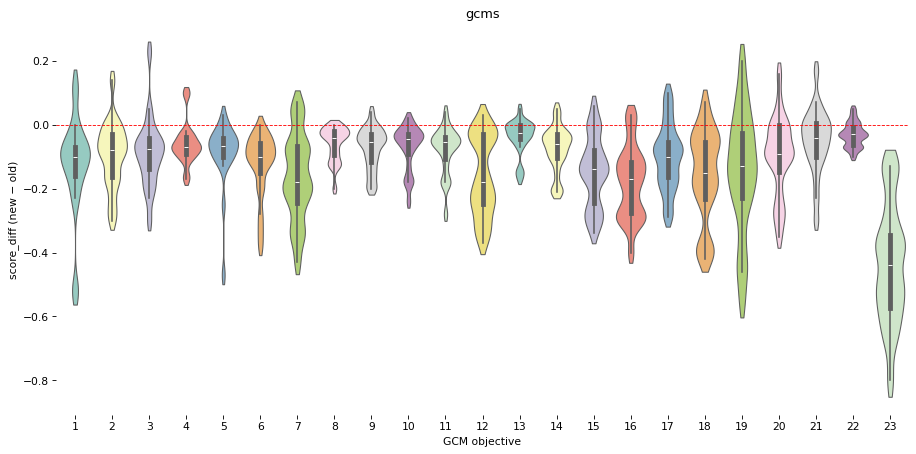

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective', figsize=(12, 6), dpi=77)

### SRF Enablers

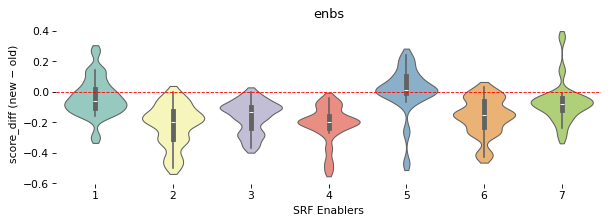

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', figsize=(8, 3), dpi=77)

### SRF Cross-Cutting Priorities

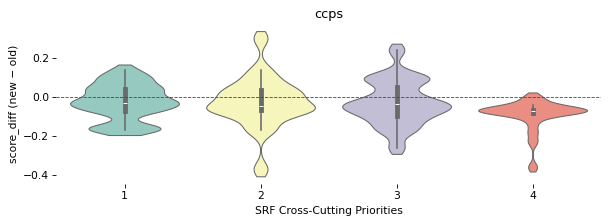

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', figsize=(8, 3), dpi=77)

## Rank changes overview

Among all themes where previous relevance score was `> 0.83` (**FUNDAMENTAL**), what percentage of them have undergone a change in rank (`rank_diff != 0`)

In [ ]:
dfs[dfs.score_old > 0.83].groupby('mapping_type').apply(lambda x: 100 * (x.rank_diff != 0).sum() / len(x)).round(1).sort_values()

mapping_type
ccps    16.7
gcms    34.3
outs    40.7
enbs    44.4
dtype: float64

## Our interpretation

The score changes overview charts show a general decrease of the scores. In other words, the **model became more conservative** following the various changes made to the prompts.

The reduction in scores is more pronounced and generalized for GCM objectives, possibly due to the additional details on **GCM objectives** (change 7 above) that now the model has access to. However, the reductions yet remain moderate in magnitude, suggesting the prompt revisions recalibrated the model's behaviour without disrupting it fundamentally. The dramatic average score reduction for GCM objective 23 is something intended. *It means that the changes to the prompt worked, although your feedback will say if further calibration is needed*.  

**SRF Enablers** showed the highest rank instability (44.4%). This is also expected due to their reframing in the prompt (change 4).

**CCPs** were relatively unaffected by the changes in terms of average scores and ranking, which is consistent with the fact that none of the changes specifically targeted CCP scoring logic.

**Caveat**: the current general analysis is based on 20 reports only. Patterns, especially for the objectives less covered by our sample of reports, should be interpreted with caution.

## Inputs we need from you

- Do you agree with the overall interpretation of the changes?
- Do you find the new behaviour to be improved? 
- Please check, in the reports you asked us to tag, how the new behaviour has changed the items classified as fundamental. Do you find that accuracy and sensitivity have improved? Do you find the new reasonings better? 

## Per evaluation report

**REMINDER**, our "RELEVANCE SCORE FRAMEWORK" is as follows:
- score >= 0.84: **FUNDAMENTAL**
- 0.66 <= score < 0.83: **RELEVANT**
- 0.34 <= score < 0.66: **PERIPHERAL**
- score < 0.34: **NOT RELEVANT**

### FINAL EVALUATION REPORT MULTI-SECTORIAL LIVELIHOOD SUPPORT TO VULNERABLE COMMUNITIES IN ZIMBABWE

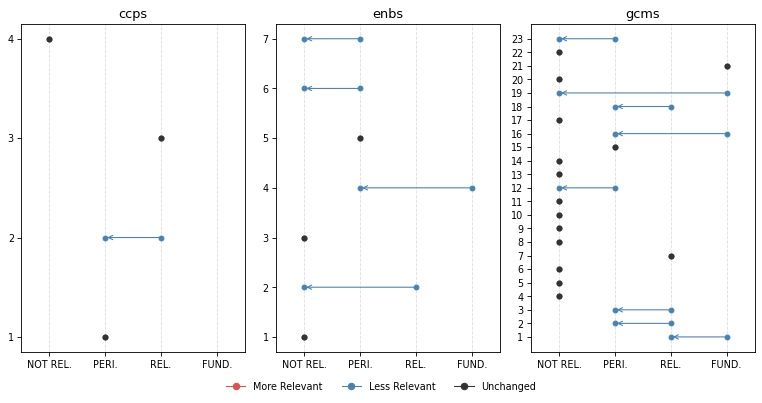

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '56e6f2bc9f55a0c6d07341ddde1283db'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 4: Data and evidence | 0.88 |
| old | gcms | 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies | 0.88 |
| old | gcms | 16: Empower migrants and societies to realize full inclusion and social cohesion | 0.92 |
| old | gcms | 19: Create conditions for migrants and diasporas to fully contribute to sustainable development in all countries | 0.85 |
| old | gcms | 21: Cooperate in facilitating safe and dignified return and readmission, as well as sustainable reintegration | 0.95 |
| new | gcms | 21: Cooperate in facilitating safe and dignified return and readmission, as well as sustainable reintegration | 0.88 |

**⬇️ No Longer Fundamental**

#### ENBS 4: Data and evidence

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.62 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Enabler 4 (Data and Evidence). The evaluation explicitly examines IOM's Displacement Tracking Matrix (DTM) as a core component of the intervention, with DTM appearing prominently in project objectives ('provide critical information on vulnerabilities and needs of returnees, IDPs and host communities through IOM's DTM'). Multiple findings directly assess IOM's data collection systems, data quality, and evidence use: the evaluation notes that DTM 'increased access to information on IDPs, returnees and host communities to government and humanitarian community' with six reports produced and distributed. The methodology section details extensive use of DTM datasets (over 4,400 household interviews across three datasets) for impact assessment, demonstrating IOM's data systems in practice. Conclusions explicitly state that 'the project through the IOM DTM has to a greater extent increased access to information.' For a synthesis specialist, the sections on Information Management and Assessments (2.2.1), the detailed description of DTM datasets used (Table 2), the findings on DTM report production and distribution, and the analysis of how DTM data informed programming decisions would be particularly valuable. This report provides direct evidence on IOM's organizational capacity in data collection, storage, sharing, and application for evidence-based decision-making.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest this report may contain content of peripheral-to-moderate relevance for a synthesis on Enabler 4 (Data and Evidence), though the institutional versus programmatic distinction requires careful consideration. The IOM Displacement Tracking Matrix (DTM) is described as a core component of the project — used to track IDPs, migrant returnees, and host communities — and the evaluation explicitly assesses its performance as part of the project's information management component. The evaluation notes that DTM reports were produced and distributed to government and humanitarian partners to improve access to primary data for targeted response. This goes somewhat beyond purely programmatic data collection: the DTM is an IOM institutional tool, and the evaluation's assessment of how it functioned to provide data for humanitarian decision-making could offer limited evidence relevant to IOM's data systems capacity. However, the evaluation's primary object remains the livelihood support programme, and the DTM assessment appears to be one sub-component rather than a central focus. A synthesis specialist focused on IOM's Data and Evidence Enabler might find the sections on Information Management and Assessments (Section 2.2.1) and the DTM datasets described in Section 3.4.3 worth a closer look, particularly for evidence on how DTM data informed programming decisions and was shared with partners — but should note that this is not an institutional-level evaluation of IOM's data systems. The value added to a synthesis would likely be marginal unless evidence on DTM's organizational role is scarce elsewhere.</details>

#### GCMS 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.72 | 3 | 2 | 1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 1. The evaluation explicitly examines IOM's Displacement Tracking Matrix (DTM) as a core project component, with substantial analysis of data collection, analysis, and dissemination on IDPs, migrant returnees, and host communities. The report directly addresses Actions 1a (comprehensive strategy for improving migration data), 1b (improving comparability of migration statistics), 1d (collecting data on effects and benefits of migration), and 1j (developing country-specific migration profiles with disaggregated data). Multiple findings assess the DTM's effectiveness in providing data to government and humanitarian partners, with specific discussion of baseline assessments, multi-sectoral village assessments, and return intention surveys. The evaluation methodology section (pages 15-17) details the use of DTM datasets collected between August-November 2022 from over 1,150 household interviews, demonstrating systematic data collection approaches. For a synthesis specialist, the sections on Information Management and Assessments (page 11), the detailed evaluation methodology describing DTM data sources (page 16, Table 2), and findings on DTM's contribution to evidence-based programming would be particularly valuable. This provides direct evidence on implementation of migration data systems and their utility for policy development.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 1. The project explicitly uses IOM's Displacement Tracking Matrix (DTM) as a core component — described as one of three distinct project components — to track IDPs, migrant returnees, and vulnerable host communities. The excerpts indicate that baseline assessments, multi-sectoral village assessments, return intention surveys, and progress monitoring reports were conducted and used to generate disaggregated data on displaced populations. The evaluation itself draws on multiple DTM datasets (over 1,500–1,700 respondents each) collected at different points. This appears to relate to GCM actions 1c (building national capacities in data collection), 1d (collecting data on effects of migration), and 1j (developing country-specific migration profiles). However, data collection is one of three project components rather than the sole focus, and the depth of analysis on data systems per se — as opposed to using data for program management — is unclear from the excerpts. Synthesis specialists would likely want to review Section 2.2.1 (Information Management and Assessments) and Section 3.4.3 (IOM DTM Secondary Data) as starting points, as well as the conclusions section referencing DTM report production and distribution. It is possible the full report contains more substantive analysis of the DTM methodology and its contribution to evidence-based policymaking than the excerpts reveal.</details>

#### GCMS 16: Empower migrants and societies to realize full inclusion and social cohesion

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.92 | 0.62 | 2 | 4 | -2 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 16. The evaluation explicitly examines social cohesion and reintegration as core project objectives, with the overarching goal to 'help internally displaced persons (IDPs), migrant returnees, and host communities reintegrate into society and strengthen their resilience' (page 9). Multiple components directly address Actions 16a (promoting mutual respect and social cohesion), 16d (inclusive labour markets and employment), 16f (community centres facilitating participation), and 16g (peer-to-peer training and skills development). The project provided income-generating activities to 1,800 households to promote economic self-sufficiency and social stability (page 12), established peer support groups as community-level forums for social cohesion (page 41), and delivered skills training for livelihood development. The evaluation findings explicitly assess 'the extent to which the project increased level of economic self-sufficiency, social stability, and psychosocial wellbeing among IDPs, returnees and host communities' (page 41). The MHPSS component through peer support groups created spaces for mutual support and social integration. For a synthesis specialist, the sections on project objectives (pages 11-12), findings on economic self-sufficiency and social stability outcomes (page 41), the analysis of peer support groups as social cohesion mechanisms (page 41), findings on IGA effectiveness in enabling community participation (page 41), and recommendations on capacity building and market linkages for sustainable integration (pages 42-43) would be particularly valuable. This provides direct evidence on reintegration programming approaches, the interplay between economic empowerment and social inclusion, and factors affecting sustainable reintegration outcomes.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts suggest this report has meaningful peripheral-to-relevant content for GCM Objective 16. The project explicitly aims at social reintegration and social cohesion — peer support groups are described as fostering 'resilience and social cohesion,' and the project targets both returnees and host communities together to facilitate reintegration. This connects to GCM actions 16a (promoting mutual respect and social cohesion), 16c (developing policy goals for inclusion), and 16d (working towards inclusive labour markets through IGA support). The IGA component supporting income-generating activities and economic participation also relates to action 16d. The evaluation's focus on 'social stability' as an outcome dimension and the peer support group model as a community integration mechanism appear relevant. However, the report's primary framing is humanitarian assistance and resilience-building rather than integration policy per se. Synthesis specialists might find the conclusions on ICRS effectiveness for social cohesion and the IGA outcomes sections worth reviewing, with the caveat that social cohesion appears as one of several outcome dimensions rather than the central analytical focus.</details>

#### GCMS 19: Create conditions for migrants and diasporas to fully contribute to sustainable development in all countries

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.3 | 4 | 9 | -5 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 19. The evaluation explicitly examines how returnees and IDPs contribute to sustainable development through economic reintegration and community participation, directly addressing Actions 19a (implementing the 2030 Agenda), 19b (integrating migration into development planning), and 19h (facilitating diaspora contributions through flexible modalities). The project's overarching objective to 'help internally displaced persons (IDPs), migrant returnees, and host communities reintegrate into society and strengthen their resilience' (page 9) aligns with creating conditions for migrants to contribute to development. The income-generating activities enabled 1,800 households to generate additional income and diversify investments, strengthening the local economy (page 41). The evaluation findings note that 'the income-generating activities have had a significant knock-on effect, not only providing financial security to vulnerable households but also allowing individuals to diversify their investments and strengthen the local economy' (page 41). The context section discusses how the project addresses structural development challenges including poverty, food insecurity, and economic fragility (pages 10-11). For a synthesis specialist, the sections on project objectives and development context (pages 9-12), findings on economic contributions and multiplier effects of IGAs (page 41), the analysis of how livelihood support enables community participation and local economic strengthening, and recommendations on market linkages and value chain development (pages 42-43) would be particularly valuable. This provides direct evidence on how reintegration programming can facilitate migrant contributions to local development, the economic impacts of returnee support, and factors affecting sustainable development outcomes in migration contexts.</details>

---

<details><summary>Reasoning (new)</summary>The project's IGA component aims to support economic reintegration and contribution to local economies by returnees, which connects loosely to GCM Objective 19's theme of migrants contributing to sustainable development. The conclusions note that IGAs have had 'knock-on effects' on the local economy. However, the report focuses on humanitarian assistance to vulnerable returnees rather than on diaspora engagement, remittance investment, or the broader development contributions of migrants that are central to GCM Objective 19. The connection is tangential — the report addresses survival-level economic reintegration rather than the development contribution mechanisms (diaspora bonds, investment funds, knowledge transfer) that GCM Objective 19 emphasizes. A synthesis specialist would likely find insufficient depth here for a synthesis on GCM Objective 19.</details>

### FINAL INTERNAL INDEPENDENT EVALUATION OF THE CAPACITY ENHANCEMENT FOR INSTITUTIONALIZED VICTIM CENTERED INVESTIGATIONS AND PROSECUTIONS OF TRAFFICKING IN PERSONS (TIP) CASES IN SOUTH AFRICA PROJECT

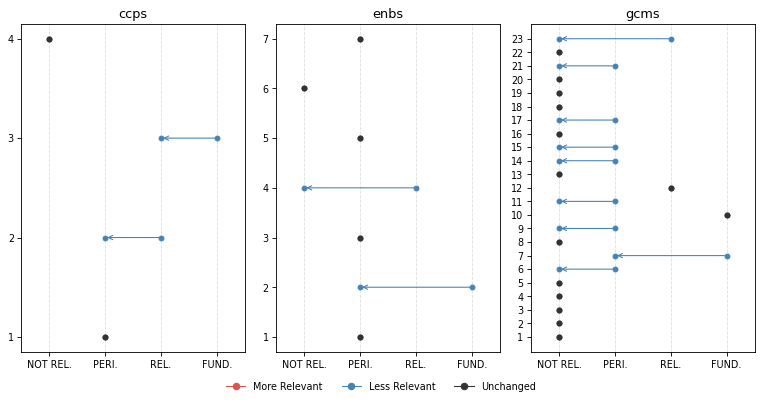

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '1d7e6d2d445145d1d350b48b72b36681'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | ccps | 3: Protection-centred | 0.88 |
| old | enbs | 2: Partnership | 0.88 |
| old | gcms | 10: Prevent, combat and eradicate trafficking in persons in the context of international migration | 0.95 |
| old | gcms | 7: Address and reduce vulnerabilities in migration | 0.88 |
| new | gcms | 10: Prevent, combat and eradicate trafficking in persons in the context of international migration | 0.97 |

**⬇️ No Longer Fundamental**

#### CCPS 3: Protection-centred

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.78 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Protection-centred approaches. The evaluation explicitly examines a project designed to promote 'victim centered investigations and prosecution' of trafficking cases, with victim protection and rights-based approaches appearing prominently in the project title, objectives, and throughout the evaluation. Multiple findings directly assess IOM's implementation of protection-centered commitments: the report evaluates direct assistance provided to 29 victims of trafficking (VOTs), analyzes the development of Standard Operating Procedures for victim care and referral, and examines capacity building aimed at ensuring 'relevant officers understand TIP and victim centered assistance.' The executive summary emphasizes that 'victim support, especially assistance in voluntary international repatriation were the most appreciated aspects of IOM's work.' Key findings address whether 'victims of TIP were now better protected or managed as a result of the project' and assess the extent to which the intervention upheld 'the rights of VOT' and placed 'the human rights and well-being of all migrants at the centre.' The evaluation also examines stakeholder coordination mechanisms designed to improve protection outcomes. For a synthesis specialist, the analysis of victim-centered approaches in the effectiveness section (4.3), the discussion of direct assistance to VOTs, the assessment of SOPs for victim protection and referral, and the findings on rights-based capacity building would be particularly valuable. This report provides direct evidence on IOM's implementation of protection-centered programming in the counter-trafficking context, including both strengths (victim assistance delivery) and gaps (limited scale of reach).</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Cross-cutting Priority 3 (Protection-centred). The project evaluated — 'Capacity Enhancement for Institutionalized Victim Centered Investigations and Prosecution of Trafficking in Persons Cases in South Africa' — is explicitly framed around victim-centered approaches to TIP management, placing the protection and wellbeing of trafficking victims at the center of its design and implementation. The excerpts suggest that protection-centred approaches are woven throughout the evaluation's objectives, findings, and conclusions. Key elements relevant to this Priority include: the development of Standard Operating Procedures for victim care and referral; direct assistance provided to 29 Victims of Trafficking (VOTs) covering protection and welfare needs; capacity building of government officials on victim identification and victim-centered assistance; and the evaluation's assessment of whether the project contributed to an 'institutionalized victim centered approach to TIP management.' The conclusions explicitly discuss the project's contribution to victim-centered TIP management as the overarching goal, and recommendations address scaling up victim assistance and protection mechanisms. The rights-based framing — referencing the Palermo Protocol, the TIP Act, and IOM's mandate to uphold human dignity — also aligns with this Priority's emphasis on rights-based approaches. However, protection-centred approaches here are assessed primarily through the lens of TIP programming effectiveness rather than as a standalone institutional commitment of IOM, which somewhat limits its direct applicability to a synthesis on IOM's organizational protection-centred commitments. Synthesis specialists would likely want to review the effectiveness and impact sections (Chapter 4, sections 4.3 and 4.5), the conclusions on victim-centered TIP management (section 5.1), and the recommendations on scaling victim assistance (section 5.2) as starting points for deeper review.</details>

#### ENBS 2: Partnership

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.55 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Partnership. The evaluation explicitly examines IOM's partnership approach with government departments and civil society organizations in counter-trafficking work, with stakeholder coordination appearing as a primary project objective and evaluation focus. Multiple findings directly assess partnership quality, noting 'very participatory nature of project implementation enhanced ownership' and 'effective stakeholder mobilization was a pivotal aspect to timely project delivery.' The coherence and effectiveness sections provide substantive analysis of IOM's coordination with national (NICTIP) and provincial (PTTs) structures, examining both strengths and weaknesses in multi-stakeholder engagement. Key recommendations specifically address sustaining partnerships ('Remain connected with PTTs but most especially NICTIP') and elevating engagement to higher political levels. For a synthesis specialist, the analysis of partnership models with government entities in Chapter 4 (sections 4.2 Coherence and 4.3 Effectiveness), the discussion of stakeholder ownership and coordination challenges, and recommendations 3-4 on political engagement and maintaining partnerships would be particularly valuable for understanding IOM's partnership development capacities in government-facing programming.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest that stakeholder engagement and coordination feature prominently in this evaluation, but on closer examination these appear to be programmatic delivery mechanisms rather than an evaluation of IOM's institutional partnership capacity. The project's core design involved engaging government departments (SAPS, DHA, DSD, NPA, DEL, DoJ, DoH), provincial task teams, and civil society organizations as implementation partners. The evaluation assesses how effectively IOM mobilized and engaged these stakeholders to deliver project outputs — SOPs, training manuals, capacity building. Recommendations 3 and 4 address maintaining engagement with NICTIP and PTTs, and Recommendation 5 calls for greater regional technical support. These touch on IOM's relational positioning with government counterparts. However, the evaluation's object appears to be the TIP programme's effectiveness, not IOM's institutional partnership frameworks, equity of partnerships, or organization-wide partnership systems. The partnership content here is primarily about programme delivery coordination rather than IOM's partnership capacity as an organizational enabler. A synthesis specialist on the Partnership Enabler might find some peripheral value in the sections on stakeholder engagement approaches and the recommendations on maintaining government relationships, but should approach this with caution given the programmatic framing.</details>

#### GCMS 7: Address and reduce vulnerabilities in migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.62 | 2 | 3 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 7, particularly Actions 7b (identification and assistance of vulnerable migrants) and 7c (gender-responsive policies addressing needs of migrant women and girls). The entire project explicitly focuses on victim-centered approaches to trafficking, which is fundamentally about addressing vulnerabilities in migration. The evaluation extensively analyzes vulnerability identification, protection mechanisms, and assistance to victims of trafficking—a core vulnerability category. Key relevant sections include: the executive summary's discussion of 'victim support, especially assistance in the voluntary international repatriation'; findings on effectiveness of victim assistance (29 VOTs assisted with 'lifesaving assistance'); analysis of gender-responsive approaches throughout; and the detailed discussion of protection and referral mechanisms in the SOPs. The evaluation explicitly examines 'holistic TIP management (Prevention, Protection, Prosecution, Partnership)' with Protection being directly relevant to vulnerability response. The findings on stakeholder coordination for victim care and the development of SOPs for victim management provide concrete evidence on vulnerability response systems. For a synthesis specialist, pay close attention to: the sections on direct assistance to VOTs, the analysis of protection mechanisms in the SOPs, findings on victim-centered approaches, and recommendations on scaling assistance. The gender dimension is particularly strong, with specific attention to vulnerabilities of women and girls in trafficking contexts.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest moderate relevance for a synthesis on GCM Objective 7, particularly around the identification, protection, and assistance of vulnerable migrants — specifically victims of trafficking. The project explicitly provided direct assistance to 29 Victims of Trafficking (VOTs), and the evaluation discusses victim-centered approaches, referral mechanisms, and protection and welfare assistance. Actions 7b (comprehensive policies for migrants in vulnerable situations) and 7k (involving local authorities in identification and referral) appear particularly related. However, vulnerability is addressed specifically through the TIP lens rather than as a broader migration vulnerability framework, and the analytical depth on vulnerability per se is limited compared to the institutional capacity-building focus. The sections on direct VOT assistance and the discussion of victim-centered TIP management in the effectiveness and impact chapters would be the most relevant for human reviewers to examine, though this report would likely be secondary to sources with broader vulnerability frameworks.</details>

### INDEPENDENT EVALUATION OF THE UNITED NATIONS PILOT PROJECT FOR STRENGTHENING MIGRANT INTEGRATION AND SOCIAL COHESION IN SOUTH AFRICA

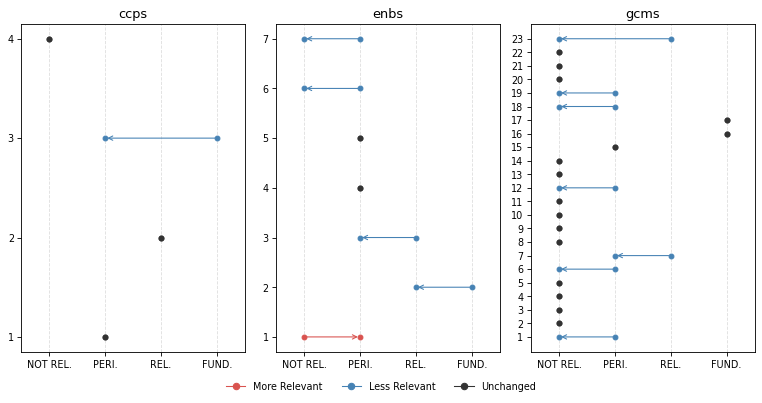

In [ ]:
plot_band_changes(dfs[dfs.evl_id == 'dba9eb1220368d28682d8531108e767d'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | ccps | 3: Protection-centred | 0.88 |
| old | enbs | 2: Partnership | 0.88 |
| old | gcms | 16: Empower migrants and societies to realize full inclusion and social cohesion | 0.94 |
| old | gcms | 17: Eliminate all forms of discrimination and promote evidence-based public discourse to shape perceptions of migration | 0.88 |
| new | gcms | 16: Empower migrants and societies to realize full inclusion and social cohesion | 0.97 |
| new | gcms | 17: Eliminate all forms of discrimination and promote evidence-based public discourse to shape perceptions of migration | 0.88 |

**⬇️ No Longer Fundamental**

#### CCPS 3: Protection-centred

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.62 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Protection-centred approaches. The Joint Programme's core objective was to strengthen protection for migrants, refugees, and asylum seekers facing xenophobic violence and discrimination—directly addressing IOM's commitment to placing human rights and well-being of migrants at the centre of operations. The evaluation explicitly examines rights-based approaches across migration programming, with the programme designed around GCM Objective 7 (address and reduce vulnerabilities in migration) and Objective 16 (empower migrants and societies to realize full inclusion). Multiple findings assess protection outcomes: establishment of early warning systems to prevent xenophobic violence, conflict resolution mechanisms, community-level peace initiatives, and a 70% reduction in reported xenophobia. The report analyzes community feedback mechanisms, multi-stakeholder forums for addressing protection risks, and the programme's responsiveness to protection crises (July 2021 riots, KZN floods). The three-pronged implementation approach of Prevention, Protection, and Empowerment is explicitly protection-centred. For a synthesis specialist, the analysis of early warning systems and conflict prevention mechanisms in the effectiveness section, the discussion of protection outcomes in vulnerable communities, the findings on community participation in decision-making, and recommendations on strengthening early warning systems would be particularly valuable. This provides direct evidence on IOM's implementation of protection-centred commitments in contexts of xenophobic violence.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed contain content with some relevance to a synthesis on Cross-cutting Priority 3 (Protection-centred), though it appears to be peripheral rather than a primary focus. The Joint Programme explicitly targets protection of migrants, refugees, and asylum seekers from xenophobic violence, and the three-pronged implementation approach of 'Prevention, Protection, and Empowerment' directly invokes protection language. References to early warning systems, conflict and crisis resolution mechanisms, and support for communities affected by the July 2021 riots and KwaZulu-Natal floods suggest some analysis of protection-oriented programming. The legislative context section discusses South Africa's NAP and the GCM's Objective 7 (addressing vulnerabilities in migration), which aligns with rights-based protection approaches. However, based on the excerpts reviewed, the evaluation does not appear to deeply analyze IOM's protection-centred institutional commitments — such as child safeguarding, PSEAH mechanisms, or community participation in decision-making — as distinct evaluation themes. Protection surfaces more as a programme design element than as a subject of dedicated evaluative analysis. A synthesis specialist might find the discussion of early warning systems and crisis response adaptations marginally useful, but would likely prioritize sources with more direct treatment of protection-centred approaches as an institutional commitment. The full report may contain more relevant content than the excerpts suggest.</details>

#### ENBS 2: Partnership

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.72 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Enabler 2 (Partnership). The evaluation explicitly examines partnership dynamics across multiple dimensions: UN inter-agency collaboration (five PUNOs working jointly), partnerships with government departments (DOJ&CD, DSD, DSAC), engagement with civil society organizations and community-based organizations, and relationships with host and migrant communities. Partnership effectiveness appears prominently throughout the evaluation questions, findings, and recommendations. Multiple findings directly assess partnership quality, coordination mechanisms (Steering Committee, PMT structures), and sustainability of partnerships—all addressing organizational capacity in partnership development and management. The coherence section (findings 3.2) provides substantive analysis of complementarities with other UN initiatives. Key recommendations (4.2.3, 4.2.9, 4.2.10, 4.2.11) specifically address strengthening partnership frameworks, joint work planning, and inter-agency collaboration. For a synthesis specialist, the analysis of multi-stakeholder forums, the 'whole-of-society' and 'whole-of-government' approaches, partnership challenges in joint implementation, and recommendations on improving partnership equity and coordination would be particularly valuable. This report provides direct evidence on IOM's partnership capacities within complex multi-actor environments.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Enabler 2 (Partnership), though with important caveats about the institutional versus programmatic distinction. The Joint Programme is itself a multi-agency partnership construct involving five PUNOs (IOM, UNHCR, UNDP, OHCHR, UN Women), and the evaluation appears to examine how well these agencies collaborated, coordinated, and leveraged their comparative advantages — which touches on IOM's institutional partnership capacity in a UN system context. The excerpts suggest substantive analysis of inter-agency coordination quality, the challenges of siloed implementation, and the effectiveness of joint governance structures (Steering Committee, PMT, EMC). Recommendations 4.2.7 through 4.2.11 appear to directly address partnership architecture — joint budgeting, shared work planning, cross-agency teambuilding, and collaboration culture — at an organizational level rather than merely as programme delivery tools. The programme's explicit 'whole-of-society' and 'whole-of-government' approach, and its engagement with civil society, government departments, and community organizations as implementing partners, also provides some institutional-level evidence on partnership models. The sections most likely worth reviewing for a synthesis specialist would be the efficiency and sustainability findings, the conclusions on inter-agency coherence, and Recommendations 4.2.3, 4.2.7–4.2.11. That said, partnership here is partly a delivery mechanism for the programme, so the institutional-level evidence is mixed rather than purely organizational.</details>

### Socio-Economic Reintegration of Returnees and other Vulnerable Households in migration affected areas severely impacted by COVID-19 Pandemic

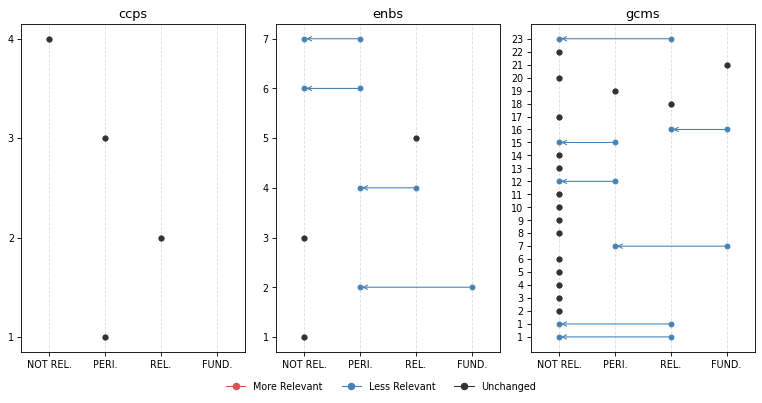

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '8dd2261100ff5d714e73b411eed043d5'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 2: Partnership | 0.88 |
| old | gcms | 16: Empower migrants and societies to realize full inclusion and social cohesion | 0.92 |
| old | gcms | 21: Cooperate in facilitating safe and dignified return and readmission, as well as sustainable reintegration | 0.94 |
| old | gcms | 7: Address and reduce vulnerabilities in migration | 0.88 |
| new | gcms | 21: Cooperate in facilitating safe and dignified return and readmission, as well as sustainable reintegration | 0.92 |

**⬇️ No Longer Fundamental**

#### ENBS 2: Partnership

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.42 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Partnership. The evaluation explicitly examines IOM's partnership model with government entities at multiple levels (national ministries, DISCOSEC, NACOSEC, district administrators, community leaders) and with implementing partners (vocational schools, NGOs like Skillshare, external consultants). Partnership effectiveness appears prominently throughout the report structure. Multiple findings directly assess partnership quality and coordination mechanisms—the project design section emphasizes 'extensive consultations, deliberations and collaboration with key stakeholders at national, district and community level.' The conclusions highlight how the project 'bolstered its efficiency by leveraging on the successes and lessons learnt' from previous partnerships. Key recommendations address improving partnership processes, particularly the suggestion to work 'together with district and community leaders to develop a scoring system' and the recommendation to work 'together with one or few ministries like Social Development and Local Government' following DISCOSEC dismantlement. For a synthesis specialist, the detailed analysis of multi-level government partnerships in Section 2.2 (Project Overview - Partnerships subsection), the findings on stakeholder collaboration effectiveness, and the recommendations on streamlining partnership structures would be particularly valuable for understanding IOM's partnership development and management capacities in emergency response contexts.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed contain some content related to partnerships, but on closer examination the partnerships described appear to function primarily as delivery mechanisms for the reintegration programme rather than as the object of evaluation. The report describes collaboration with multiple government ministries (MoLG, MoSD, MoLE), DISCOSEC, NACOSEC, community leaders, and vocational schools as implementation partners. There is some discussion of how these partnerships were structured and their role in project design and delivery. However, based on the excerpts, there is no substantive analysis of IOM's institutional partnership frameworks, equity of partnerships with national/local actors, or sustainability of partnership models at an organizational level. The recommendation about working with specific ministries in future programming (MoSD and Local Government) touches on partnership strategy but remains programmatic in framing. A synthesis specialist focused on IOM's Partnership Enabler would find limited institutional evidence here, though the multi-stakeholder coordination model described might marginally warrant attention if evidence from other sources is scarce.</details>

#### GCMS 16: Empower migrants and societies to realize full inclusion and social cohesion

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.92 | 0.72 | 2 | 2 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 16, particularly Actions 16a (promoting mutual respect and social cohesion), 16c (developing integration policy goals), 16d (promoting labour market integration), and 16f (establishing community-level integration programs). Social cohesion and community integration are explicit primary objectives of the project, appearing prominently in Outcome 3: 'Government of Lesotho - through Ministry of Local Government has improved its ability to enhance social unity/cohesion through community development initiatives' (page 12). The evaluation provides substantial analysis of community development projects/cooperatives designed specifically to promote social cohesion among COVID-19-affected communities. Key findings demonstrate strong commitment and collaboration in community projects, with members determined to support their cooperatives through monthly subscriptions, marketing products to friends and relatives, and protecting project sites (page 32). The vocational training component directly addresses labour market integration (Action 16d), with 99% of trainees graduating and receiving start-up kits and capital to establish businesses (page 32). The report documents comprehensive pre-departure and post-arrival support (Action 16b) through business coaching covering 'stock control, record keeping and costing' (page 22). Gender empowerment (Action 16e) is explicitly addressed, with 60% of trainees being female and deliberate efforts to eliminate gender-based restrictions on economic participation (page 33). For a synthesis specialist, the sections on community development projects (pages 17-18, 32), the analysis of social cohesion outcomes in visited cooperatives (page 32), the vocational training and business coaching components (pages 20-22), and the conclusions on promoting collaboration among severely impacted communities (page 32) would be particularly valuable. This represents a well-documented case study of community-based integration and social cohesion programming in a return and reintegration context.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report appears likely to contribute meaningful evidence to a synthesis on GCM Objective 16. Social cohesion is an explicit project outcome (Outcome 3: Government of Lesotho improved ability to enhance social unity/cohesion through community development initiatives), and the evaluation assesses community development cooperatives specifically designed to promote social cohesion among returnees and host communities. Actions 16a (mutual respect and integration policies), 16d (labour market integration), and 16f (community centres/programmes for migrant participation) appear most related. The conclusions section discusses community commitment and collaboration as indicators of social cohesion progress. The community development projects section and the conclusions on social cohesion outcomes would appear particularly valuable for human reviewers to prioritize. The report likely offers evidence on what community-level reintegration and social cohesion programming looks like in a low-income, migration-affected context, though the short project duration limits depth of impact evidence.</details>

#### GCMS 7: Address and reduce vulnerabilities in migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.45 | 3 | 4 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 7, particularly Actions 7b (providing support to migrants in vulnerable situations) and 7h (facilitating transitions to regular status and reducing precariousness). The evaluation explicitly examines a comprehensive vulnerability-focused intervention targeting returnees 'severely impacted by COVID-19' who faced 'loss of livelihood,' food insecurity, and destitution (pages 10-11). Multiple rapid assessments documented specific vulnerabilities: 73% lacked food, 56% lost employment, and returnees faced ongoing challenges including lack of income (90%), unemployment (70%), and poor health (28%) (Table 7, page 19). The project design deliberately targeted vulnerable populations through rigorous selection criteria and provided multi-dimensional support including humanitarian assistance, skills training, start-up capital, and psychosocial support. Gender dimensions are explicitly addressed, with 60% of trainees being female (page 33). The findings section documents outcomes for 200 vulnerable returnees who received vocational training, with 99% graduating and 97% participating in business coaching (page 32). For a synthesis specialist, the sections on beneficiary identification and assessment (pages 17-19), the comprehensive support model combining immediate humanitarian assistance with longer-term livelihood support (pages 11, 20-22), and the conclusions on vulnerability reduction (pages 32-33) would be particularly valuable. This represents a well-documented case study of addressing migrant vulnerabilities through integrated reintegration programming.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts suggest meaningful, though not primary, content relevant to GCM Objective 7. The project explicitly targets vulnerable returnees and COVID-19-affected households, with rapid assessments identifying vulnerability profiles (food insecurity, unemployment, lack of PPEs). Gender-responsive targeting is discussed, with women identified as disproportionately affected. The evaluation assesses how well the project identified and assisted migrants in vulnerable situations. Actions 7b (comprehensive policies for migrants in vulnerability) and 7c (gender-responsive migration policies) appear most related. However, vulnerability is addressed primarily as a targeting criterion for livelihood support rather than as a standalone analytical theme. A synthesis specialist might find the targeting methodology and vulnerability profiling sections worth reviewing, but should note this is not the central analytical focus of the evaluation.</details>